In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor

In [2]:
# Start with orders
df = pd.read_parquet('../data/processed/df_eda.parquet')

In [3]:
print("Shape:", df.shape)
print("Missing:\n", df.isnull().sum())

Shape: (87413, 24)
Missing:
 order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_timestamp        0
order_estimated_delivery_date    0
payment_sequential               0
payment_type                     0
payment_installments             0
payment_value                    0
product_id                       0
seller_id                        0
price                            0
shipping_charges                 0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
product_category_name            0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_volume_cm3               0
dtype: int64


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87413 entries, 0 to 87412
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       87413 non-null  object        
 1   customer_id                    87413 non-null  object        
 2   order_status                   87413 non-null  category      
 3   order_purchase_timestamp       87413 non-null  datetime64[ns]
 4   order_approved_at              87413 non-null  datetime64[ns]
 5   order_delivered_timestamp      87413 non-null  datetime64[ns]
 6   order_estimated_delivery_date  87413 non-null  datetime64[ns]
 7   payment_sequential             87413 non-null  int64         
 8   payment_type                   87413 non-null  category      
 9   payment_installments           87413 non-null  int16         
 10  payment_value                  87413 non-null  float64       
 11  product_id     

In [5]:
df['order_id'] = df['order_id'].astype('category')
df['customer_id'] = df['customer_id'].astype('category')
df['customer_zip_code_prefix'] = df['customer_zip_code_prefix'].astype('category')

# Feature Engineering

### Creating Features

Time Based features

In [6]:
df['delivery_time_days'] = (
    (df['order_delivered_timestamp'] - df['order_purchase_timestamp']).dt.days
)

df['approval_time_hours'] = (
    (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / 3600
)

df['delivery_delay_days'] = (
    (df['order_delivered_timestamp'] - df['order_estimated_delivery_date']).dt.days
)

Cost features

In [7]:
df['total_cost'] = df['price'] + df['shipping_charges']

df['shipping_ratio'] = df['shipping_charges'] / (df['price'] + 1e-5)

Product density

In [8]:
df['product_density'] = df['product_weight_g'] / (df['product_volume_cm3'] + 1e-5)

Time features

In [9]:
df['order_month'] = df['order_purchase_timestamp'].dt.month
df['order_dayofweek'] = df['order_purchase_timestamp'].dt.dayofweek
df['is_weekend'] = df['order_dayofweek'].isin([5, 6]).astype(int)

In [10]:
df[['delivery_time_days', 'approval_time_hours', 'delivery_delay_days', 'total_cost', 'shipping_ratio', 'product_density', 'order_month', 'order_dayofweek']].describe()

,delivery_time_days,approval_time_hours,delivery_delay_days,total_cost,shipping_ratio,product_density,order_month,order_dayofweek
count,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000
mean,11.968689,10.371209,-12.130404,386.536872,0.826308,0.190776,6.032856,2.746182
std,9.277935,20.938565,10.039304,560.813861,4.051982,0.757975,3.231184,1.957856
min,0.000000,0.000000,-147.000000,1.140000,0.000000,0.000318,1.000000,0.000000
25%,6.000000,0.215278,-17.000000,107.720000,0.072984,0.067200,3.000000,1.000000
50%,10.000000,0.344722,-13.000000,184.750000,0.221800,0.112000,6.000000,3.000000
75%,15.000000,14.833056,-7.000000,438.450000,0.607091,0.191250,8.000000,4.000000
max,209.000000,741.443611,188.000000,6738.820000,205.279938,65.909089,12.000000,6.000000


# Fixing Data

Finding Outliers

In [11]:
import numpy as np

features = [
    'delivery_time_days',
    'approval_time_hours',
    'delivery_delay_days',
    'shipping_ratio',
    'product_density'
]

for col in features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"\n{col}")
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Outlier %:", len(outliers) / len(df))


delivery_time_days
Lower bound: -7.5
Upper bound: 28.5
Outlier %: 0.049660805600997567

approval_time_hours
Lower bound: -21.711388888888887
Upper bound: 36.75972222222222
Outlier %: 0.09027261391326233

delivery_delay_days
Lower bound: -32.0
Upper bound: 8.0
Outlier %: 0.0448102684955327

shipping_ratio
Lower bound: -0.7281764696538908
Upper bound: 1.4082508087724537
Outlier %: 0.10898836557491448

product_density
Lower bound: -0.1188750000358012
Upper bound: 0.3773249999449807
Outlier %: 0.08782446546852299


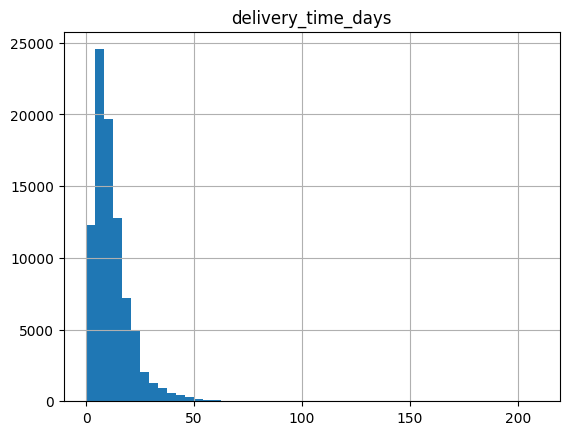

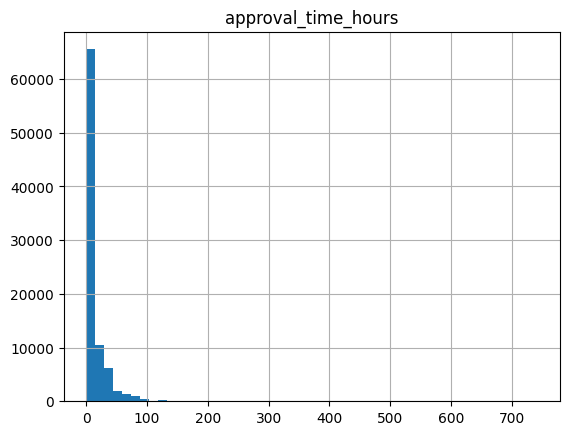

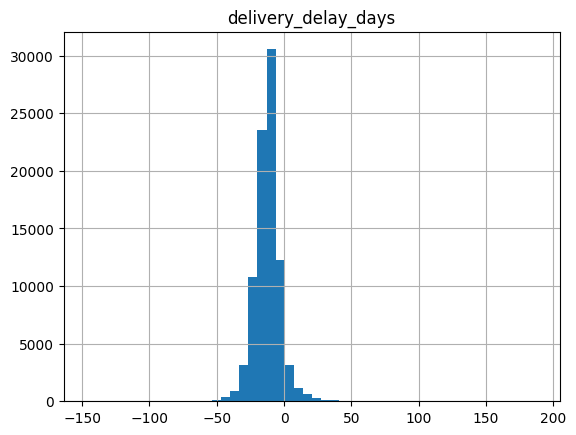

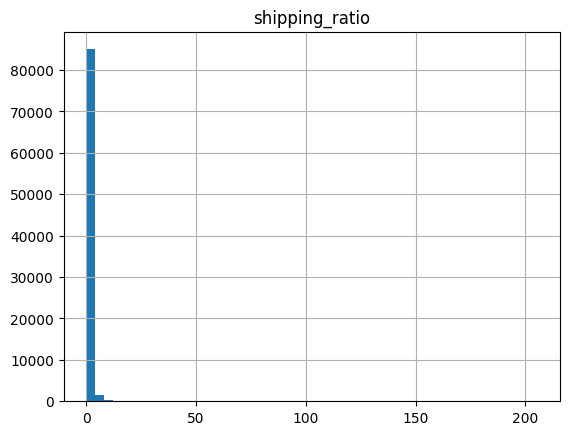

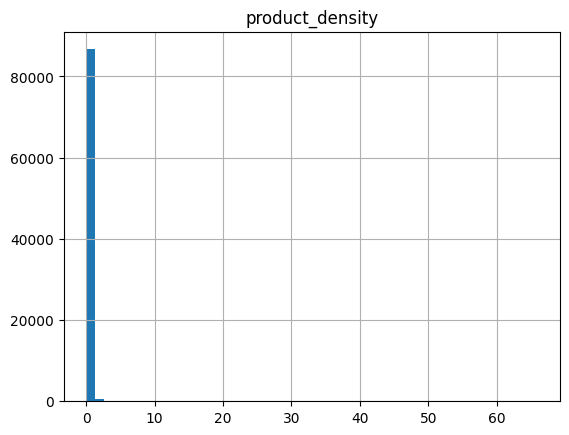

In [12]:
import matplotlib.pyplot as plt

for col in features:
    plt.figure()
    df[col].hist(bins=50)
    plt.title(col)
    plt.show()

In [13]:
print("Delivery Delay")
print((df['delivery_delay_days'] < -30).mean())

Delivery Delay
0.026574994566025648


In [14]:
print("Shipping Ratio")
print(df[df['shipping_ratio'] > 10][['price', 'shipping_charges']].head())

Shipping Ratio
     price  shipping_charges
229   5.99             78.84
466   7.59             79.43
471   3.50             41.29
583   2.20             47.55
634  16.90            171.50


In [15]:
print("Approval Time")
display( df[df['approval_time_hours'] > 100][
    ['order_purchase_timestamp', 'order_approved_at']
].head())

Approval Time


,order_purchase_timestamp,order_approved_at
24,2017-12-30 02:36:20,2018-01-04 23:17:35
60,2017-03-30 21:59:17,2017-04-04 05:45:23
103,2018-04-20 09:01:16,2018-04-24 18:35:57
517,2018-06-30 12:14:21,2018-07-05 16:27:53
568,2018-02-09 07:25:50,2018-02-16 07:50:26


In [16]:
print("product density")
display(df[df['product_density'] > 10][
    ['product_weight_g', 'product_volume_cm3']
].head())

product density


,product_weight_g,product_volume_cm3
1061,6400.0,352.0
1779,22100.0,352.0
3366,14100.0,352.0
4059,6050.0,528.0
4799,22175.0,2052.0


### Data Fixing

Delivery Time Days

In [17]:
df['log_delivery_time'] = np.log1p(df['delivery_time_days'])

Approval Time Hours

In [18]:
df['approval_time_hours'] = df['approval_time_hours'].clip(0, 168)  # 7 days

Delivery Delay Days

In [19]:
df['delivery_delay_days'] = df['delivery_delay_days'].clip(-30, 30)

Shipping Ratio

In [20]:
df['log_shipping_ratio'] = np.log1p(df['shipping_ratio'])

Product Density

In [21]:
df['product_density'] = df['product_density'].clip(0, 10)

### Checking Data

In [22]:
print(df.isnull().sum().sum())

0


In [23]:
import numpy as np

print(np.isinf(df.select_dtypes(include=[np.number])).sum().sum())

0


In [24]:
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,payment_sequential,payment_installments,payment_value,price,shipping_charges,product_weight_g,...,approval_time_hours,delivery_delay_days,total_cost,shipping_ratio,product_density,order_month,order_dayofweek,is_weekend,log_delivery_time,log_shipping_ratio
count,87413,87413,87413,87413,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,...,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000
mean,2017-12-29 22:08:00.051639808,2017-12-30 08:30:16.404482048,2018-01-11 08:33:03.465502976,2018-01-22 18:57:26.837426944,1.097400,2.963987,268.788524,342.292224,44.244648,2081.968506,...,10.292836,-12.012367,386.536872,0.826308,0.182799,6.032856,2.746182,0.225641,2.363521,0.368378
min,2016-10-03 09:44:50,2016-10-04 09:43:32,2016-10-11 13:46:32,2016-10-27 00:00:00,1.000000,0.000000,0.000000,0.850000,0.000000,2.000000,...,0.000000,-30.000000,1.140000,0.000000,0.000318,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2017-09-10 20:15:46,2017-09-11 15:30:18,2017-09-20 20:27:47,2017-10-02 00:00:00,1.000000,1.000000,84.330000,59.650000,20.040000,300.000000,...,0.215278,-17.000000,107.720000,0.072984,0.067200,3.000000,1.000000,0.000000,1.945910,0.070443
50%,2018-01-17 11:59:12,2018-01-17 16:35:21,2018-01-30 22:48:40,2018-02-14 00:00:00,1.000000,2.000000,171.860000,136.900000,35.010000,700.000000,...,0.344722,-13.000000,184.750000,0.221800,0.112000,6.000000,3.000000,0.000000,2.397895,0.200325
75%,2018-05-02 23:06:51,2018-05-03 09:12:19,2018-05-14 15:54:50,2018-05-24 00:00:00,1.000000,4.000000,313.550000,399.200000,57.150000,1800.000000,...,14.833056,-7.000000,438.450000,0.607091,0.191250,8.000000,4.000000,0.000000,2.772589,0.474425
max,2018-08-29 14:52:00,2018-08-29 15:05:22,2018-10-17 13:22:46,2018-10-25 00:00:00,26.000000,24.000000,7274.880000,6735.000000,409.680000,40425.000000,...,168.000000,30.000000,6738.820000,205.279938,10.000000,12.000000,6.000000,1.000000,5.347108,5.329234
std,NaN,NaN,NaN,NaN,0.742207,2.794934,344.834902,559.776730,37.657927,3734.926025,...,19.754494,8.934977,560.813861,4.051982,0.353039,3.231184,1.957856,0.418006,0.634378,0.479195


In [25]:
cols_to_drop = [
    'order_id',
    'customer_id',
    'product_id',
    'seller_id',
    'order_delivered_timestamp',
    'order_estimated_delivery_date'
]

df_model = df.drop(columns=cols_to_drop)

In [26]:
print(df_model['payment_value'].describe())

count    87413.000000
mean       268.788524
std        344.834902
min          0.000000
25%         84.330000
50%        171.860000
75%        313.550000
max       7274.880000
Name: payment_value, dtype: float64


In [27]:
df_model.corr(numeric_only=True)['payment_value'].sort_values(ascending=False)

payment_value           1.000000
total_cost              0.015438
price                   0.014528
shipping_charges        0.013955
is_weekend              0.008981
payment_sequential      0.005936
log_delivery_time       0.005766
product_width_cm        0.004006
delivery_time_days      0.003489
order_dayofweek         0.001139
product_density         0.000449
product_weight_g        0.000288
product_length_cm      -0.000478
delivery_delay_days    -0.001332
product_volume_cm3     -0.001729
shipping_ratio         -0.002351
product_height_cm      -0.002796
approval_time_hours    -0.003430
log_shipping_ratio     -0.003693
payment_installments   -0.004750
order_month            -0.008170
Name: payment_value, dtype: float64

# Feature Engineering Part 2

Price Buckets

In [28]:
df['price_bucket'] = pd.qcut(df['price'], q=5, labels=False)

Shipping Category

In [29]:
df['high_shipping'] = (df['shipping_ratio'] > 0.5).astype(int)

Expensive Product Flag

In [30]:
df['is_expensive'] = (df['price'] > df['price'].median()).astype(int)

Large Product Flag

In [31]:
df['is_large_product'] = (df['product_volume_cm3'] > df['product_volume_cm3'].median()).astype(int)

Installment Behavior

In [32]:
df['high_installments'] = (df['payment_installments'] > 3).astype(int)

In [33]:
df['log_payment_value'] = np.log1p(df['payment_value'])

# Data Validation

In [34]:
print("Missing:", df.isnull().sum().sum())

import numpy as np
print("Infinite:", np.isinf(df.select_dtypes(include=[np.number])).sum().sum())

Missing: 0
Infinite: 0


In [35]:
df[['price_bucket', 'high_shipping', 'is_expensive', 
    'is_large_product', 'high_installments', 
    'log_payment_value']].describe()

,price_bucket,high_shipping,is_expensive,is_large_product,high_installments,log_payment_value
count,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000
mean,1.982039,0.293869,0.499685,0.499743,0.288424,5.045839
std,1.401218,0.455535,0.500003,0.500003,0.453032,1.134738
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,4.446526
50%,2.000000,0.000000,0.000000,0.000000,0.000000,5.152482
75%,3.000000,1.000000,1.000000,1.000000,1.000000,5.751143
max,4.000000,1.000000,1.000000,1.000000,1.000000,8.892320


In [36]:
for col in df.select_dtypes(include='category').columns:
    print(col, df[col].nunique())

order_id 87413
customer_id 87413
order_status 1
payment_type 4
product_id 26849
seller_id 2822
customer_zip_code_prefix 13841
customer_city 3713
customer_state 27
product_category_name 71


In [37]:
df.corr(numeric_only=True)['log_payment_value'].sort_values(ascending=False)

log_payment_value       1.000000
payment_value           0.728726
shipping_charges        0.023968
high_shipping           0.011403
is_weekend              0.006912
is_expensive            0.003817
high_installments       0.003797
payment_installments    0.002684
product_density         0.001802
log_delivery_time       0.001687
product_weight_g        0.000835
price_bucket           -0.000446
delivery_time_days     -0.001151
log_shipping_ratio     -0.001356
product_volume_cm3     -0.001723
order_dayofweek        -0.002145
approval_time_hours    -0.002160
product_length_cm      -0.002333
total_cost             -0.002516
product_height_cm      -0.002878
product_width_cm       -0.002985
payment_sequential     -0.003942
price                  -0.004133
shipping_ratio         -0.005237
delivery_delay_days    -0.009061
order_month            -0.010159
is_large_product       -0.010673
Name: log_payment_value, dtype: float64

In [38]:
df.to_parquet('../data/processed/feature_engineered.parquet', index=False)